# Customer Churn Prediction
## 05 - Model Evaluation, Explainability & Business Insights

This notebook focuses on interpreting the best-performing model (Random Forest) and translating predictions into actionable business insights.

We will:
- Evaluate final model performance
- Perform feature importance analysis
- Apply SHAP explainability
- Segment customers by churn risk
- Conduct business cost-benefit analysis
- Provide actionable recommendations

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import shap
import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [11]:
BASE_DIR = Path().resolve().parent

file_path = BASE_DIR / "Data" / "processed" / "feature_engineered_churn.csv"

df = pd.read_csv(file_path)

df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,IsNewCustomer,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,HighMonthlyCharges,CustomerValue,TenureGroup_1-2yr,TenureGroup_2-4yr,TenureGroup_4+yr,AvgMonthlySpend,Churn
0,0,1,29.85,29.85,1,False,True,False,False,True,...,False,True,False,0,29.85,False,False,False,14.925000,0
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,True,0,1936.30,False,True,False,53.985714,0
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,True,0,107.70,False,False,False,36.050000,1
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,0,1903.50,False,True,False,40.016304,0
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,True,False,1,141.40,False,False,False,50.550000,1


In [12]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
best_model = joblib.load("../models/best_random_forest.pkl")

best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](37,)","['SeniorCitizen','tenure','MonthlyCharges',...,'TenureGroup_2-4yr', 'TenureGroup_4+yr','AvgMonthlySpend']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,37
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatwei

In [14]:
y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:, 1]

## Classification Report

The classification report provides a detailed breakdown of model performance across both churn and non-churn customers.

Key metrics include:

- Precision
- Recall
- F1-Score

Particular attention is paid to churn recall because failing to identify customers who are likely to leave can result in direct revenue loss.

In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1035
           1       0.54      0.76      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



### Key Insight

The model achieves an overall accuracy of 77% and demonstrates a balanced ability to distinguish between churning and non-churning customers.

For the churn class, the model achieves a recall of 76%, meaning it successfully identifies approximately three out of every four customers who are likely to leave. This is particularly valuable from a business perspective because missed churners represent lost revenue opportunities.

The precision score of 54% indicates that some customers flagged as high risk will ultimately remain with the company. However, in churn management, this trade-off is generally acceptable because the cost of a retention campaign is often lower than the cost of customer attrition.

Overall, the model provides a strong foundation for proactive customer retention initiatives.

## ROC-AUC Analysis

ROC-AUC measures the model's ability to distinguish between churn and non-churn customers across all possible classification thresholds.

Values closer to 1 indicate stronger discriminatory power.

In [16]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8425275775659408


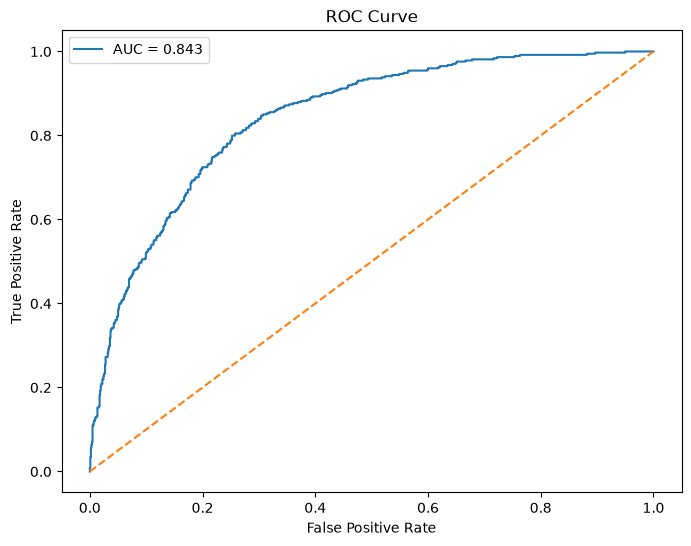

In [17]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

### ROC-AUC Interpretation

The model achieved a ROC-AUC score of 0.843, indicating strong discriminatory power between customers who churn and those who remain.

In practical terms, the model has an 84.3% probability of ranking a randomly selected churning customer higher in churn risk than a randomly selected non-churning customer.

This suggests that the model captures meaningful behavioral patterns associated with churn and can reliably support customer retention decision-making.


## Confusion Matrix

While overall metrics such as accuracy, precision, recall, and F1-score provide a summary of model performance, the confusion matrix offers a more detailed view of how predictions are distributed across actual customer outcomes.

This analysis helps identify:

- Customers correctly predicted to remain with the company.
- Customers correctly predicted to churn.
- Customers incorrectly flagged as churn risks.
- Customers who were missed by the model despite eventually churning.

Understanding these outcomes is critical because different prediction errors have different business implications.

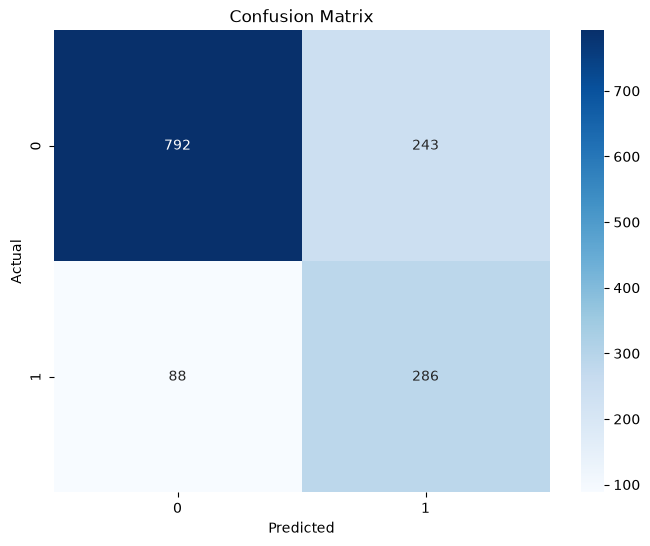

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [25]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

confusion_summary = pd.DataFrame({
    "Metric": [
        "True Negatives",
        "False Positives",
        "False Negatives",
        "True Positives"
    ],
    "Count": [
        tn,
        fp,
        fn,
        tp
    ]
})

confusion_summary

,Metric,Count
0,True Negatives,792
1,False Positives,243
2,False Negatives,88
3,True Positives,286


## Confusion Matrix Interpretation

The confusion matrix provides a detailed view of how the model performs when predicting customer churn.

The model correctly identified **792 customers who remained with the company** and **286 customers who ultimately churned**. This demonstrates that the model is capable of distinguishing between loyal customers and customers at risk of leaving.

Of particular importance, the model missed only **88 churners** (false negatives). These represent customers who left the company despite being predicted to stay. Minimizing these cases is critical because they represent lost retention opportunities and potential revenue loss.

The model also generated **243 false positives**, meaning some customers were incorrectly classified as likely to churn. While this may result in unnecessary retention efforts, the cost of these interventions is generally lower than the cost of losing a customer altogether.

### Business Interpretation

The model is designed to prioritize the identification of potential churners, which is reflected in its relatively strong recall performance. By successfully detecting a large proportion of customers who are likely to leave, the model can support proactive retention campaigns and reduce customer attrition.

Overall, the confusion matrix suggests that the model achieves a practical balance between churn detection and prediction accuracy, making it a valuable tool for customer retention decision-making.

## Feature Importance

Random Forest provides feature importance scores that indicate which variables contribute most to the model's predictions.

Higher scores indicate greater influence on churn prediction.

In [19]:
rf_model = best_model.named_steps["model"]

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
1,tenure,0.118479
3,TotalCharges,0.094816
26,Contract_Two year,0.090246
32,CustomerValue,0.082694
36,AvgMonthlySpend,0.081815
11,InternetService_Fiber optic,0.074716
2,MonthlyCharges,0.071224
29,PaymentMethod_Electronic check,0.038496
4,IsNewCustomer,0.034116
25,Contract_One year,0.030618


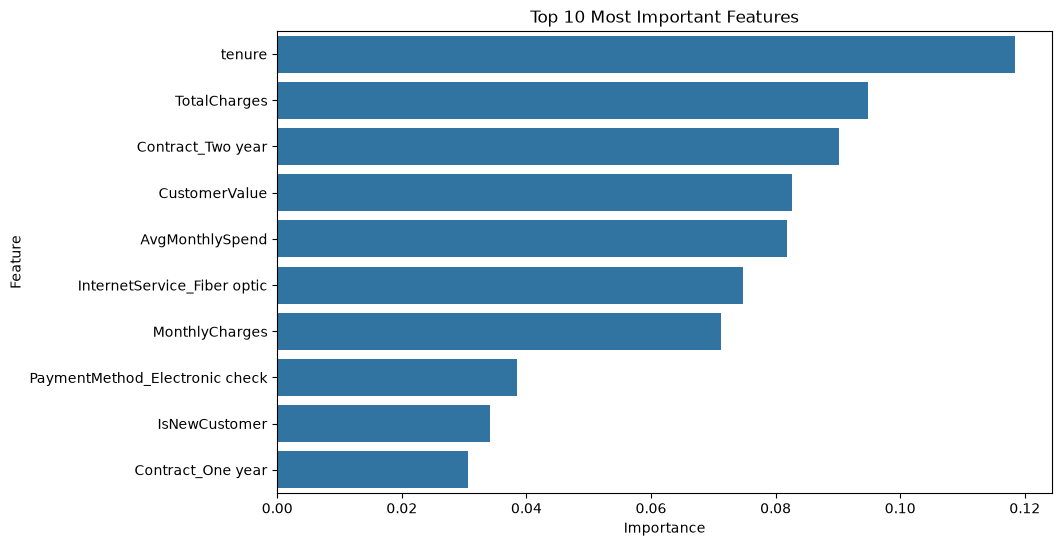

In [20]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features")

plt.show()

### Feature Importance Analysis

The feature importance results reveal that customer longevity and contract structure are the strongest drivers of churn prediction.

Customer tenure emerged as the most influential feature, indicating that newer customers are significantly more likely to leave than long-standing customers. Contract-related variables, particularly two-year and one-year agreements, also play a major role, reinforcing the earlier finding that long-term contracts reduce churn risk.

Financial indicators such as Total Charges, Average Monthly Spend, Customer Value, and Monthly Charges were also among the most influential predictors, suggesting that customer spending behavior is closely linked to retention outcomes.

Additionally, Fiber Optic internet service and Electronic Check payment methods appear among the top predictors, further supporting patterns identified during exploratory data analysis.


#### Business Implications:

Overall, the feature importance analysis suggests that the most effective retention strategy should focus on:
- *** New and recently acquired customers. ***
- *** Customers on month-to-month contracts. ***
- *** High-spending customers. ***
- *** Fiber Optic subscribers. ***
- *** Customers using Electronic Check payment methods. ***

Targeting these segments is likely to deliver the greatest reduction in churn and the highest return on retention investments.


## SHAP Feature Importance

SHAP (SHapley Additive exPlanations) is used to interpret the predictions of the final Random Forest model.

Unlike traditional feature importance, SHAP quantifies both the magnitude and direction of each feature's impact on churn predictions.

Features appearing at the top of the chart have the strongest influence on the model's decision-making process, while the color scale indicates whether high or low feature values increase churn risk.

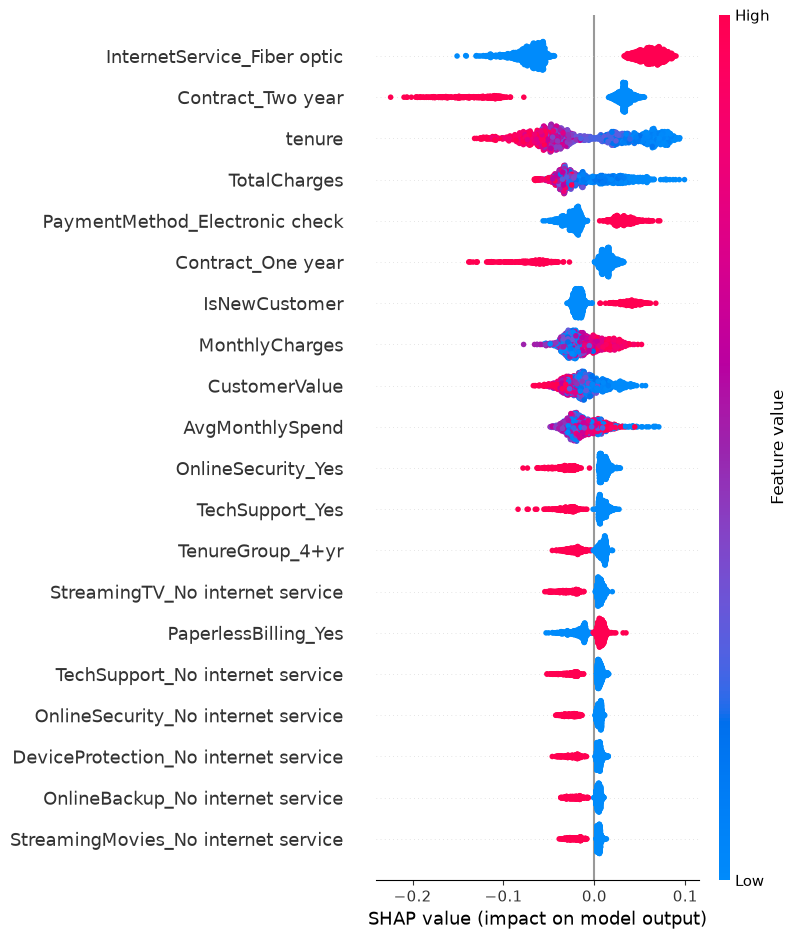

In [21]:
rf_model = best_model.named_steps["model"]

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values[:, :, 1],
    X_test
)

### SHAP Analysis Interpretation

The SHAP analysis provides a deeper understanding of how individual features influence churn predictions.

Consistent with the feature importance results, tenure, contract type, spending behavior, and internet service characteristics exert the strongest influence on churn risk. Customers with shorter tenure periods, higher monthly spending, month-to-month contract structures, and Fiber Optic subscriptions are more likely to be classified as churn risks.

The SHAP results reinforce the conclusions drawn from the exploratory analysis and provide additional confidence that the model is learning meaningful business relationships rather than random patterns within the data.

These insights can be used to design targeted retention strategies for the most vulnerable customer segments.

## Customer Risk Segmentation

Predicting whether a customer will churn is valuable, but businesses often need a more practical way to prioritize intervention efforts.

To support decision-making, customers are grouped into risk categories based on their predicted probability of churn:

- **Low Risk:** Less than 30% predicted probability of churn
- **Medium Risk:** Between 30% and 60% predicted probability of churn
- **High Risk:** Greater than 60% predicted probability of churn

This segmentation enables the business to allocate retention resources more efficiently by focusing attention on customers most likely to leave.

In [22]:
df_eval = X_test.copy()

df_eval["Churn_Prob"] = y_prob

def risk_level(prob):
    if prob < 0.3:
        return "Low Risk"
    elif prob < 0.6:
        return "Medium Risk"
    else:
        return "High Risk"

df_eval["Risk_Level"] = df_eval["Churn_Prob"].apply(risk_level)

risk_counts = df_eval["Risk_Level"].value_counts()

risk_summary = pd.DataFrame({
    "Count": risk_counts,
    "Percentage": round((risk_counts / len(df_eval)) * 100, 2)
})

risk_summary

,Count,Percentage
Risk_Level,,
Low Risk,658,46.70
High Risk,425,30.16
Medium Risk,326,23.14


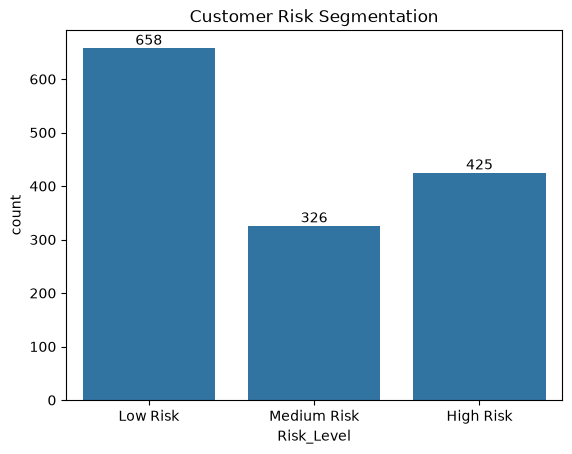

In [23]:
ax = sns.countplot(
    data=df_eval,
    x="Risk_Level",
    order=["Low Risk","Medium Risk","High Risk"]
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Risk Segmentation")

plt.show()

### Risk Segmentation Insights

The model classified 46.7% of customers as Low Risk, 23.1% as Medium Risk, and 30.2% as High Risk.

The High-Risk segment represents nearly one-third of the evaluated customer base, indicating a substantial group that may benefit from proactive retention initiatives. These customers should be prioritized for targeted engagement campaigns, loyalty incentives, or service reviews.

The Medium-Risk segment presents an opportunity for preventative action, where personalized communication and customer experience improvements may help reduce future churn.

Meanwhile, the Low-Risk segment appears relatively stable and requires only routine customer relationship management activities.


## Business Impact Analysis

Building an accurate churn prediction model is only valuable if it can create measurable business outcomes.

In this section, we estimate the potential financial impact of using the model to proactively identify high-risk customers and target them with retention campaigns.

The objective is to compare the estimated cost of customer loss against the cost of proactive retention efforts and quantify the potential savings generated by the model.

In [24]:
cost_churn = 100
cost_retention = 20

high_risk = df_eval[df_eval["Churn_Prob"] > 0.6]

loss_without_model = len(high_risk) * cost_churn

cost_with_model = len(high_risk) * cost_retention

savings = loss_without_model - cost_with_model

print("Estimated Business Savings:", savings)

Estimated Business Savings: 34000


## Business Impact Interpretation

Using the model to identify and target high-risk customers could generate an estimated business value of approximately **$34,000** under the assumptions used in this analysis.

The estimate compares the potential cost of customer churn against the cost of executing retention interventions for customers identified as high risk.

### Assumptions

* Cost of losing a customer = $100
* Cost of retention intervention = $20
* Customers with churn probability above 60% are classified as high risk

Although the figures are illustrative, the analysis demonstrates how predictive analytics can move beyond forecasting and directly support revenue preservation strategies.

The results highlight the potential financial benefits of focusing retention resources on customers most likely to churn.


## Strategic Recommendations

Based on the exploratory analysis, machine learning results, feature importance rankings, and SHAP explanations, the following actions are recommended:

1. Prioritize retention efforts for newly acquired customers, as shorter tenure is the strongest predictor of churn.
2. Encourage customers to transition from month-to-month contracts to longer-term agreements through incentives and loyalty programs.
3. Investigate customer satisfaction among Fiber Optic subscribers, as this segment consistently demonstrates elevated churn risk.
4. Review pricing structures and value propositions for customers with high monthly spending to reduce price-related attrition.
5. Develop targeted retention campaigns for customers classified as High Risk by the model.
6. Monitor customers using Electronic Check payment methods, as this group exhibits higher churn tendencies than other payment segments.

By focusing on these customer groups, the organization can reduce churn, improve customer lifetime value, and maximize the return on retention investments.
